# Magnetic Diagnostics Processing

## Overview

This notebook is a first-draft shell for documenting magnetic diagnostics processing in the VAFT pipeline. It covers raw magnetic diagnostics, including plasma current, flux loops, and poloidal magnetic probes, and outlines the planned preprocessing, filtering, calibration, and processed signal format.

## Objectives

- Identify the raw magnetic diagnostics required by the pipeline.
- Describe preprocessing, filtering, baseline correction, and calibration steps.
- Define a consistent processed signal format for downstream analysis.
- Clarify how magnetic diagnostics feed eddy-current, EFIT, and stability workflows.

## Expected Inputs

- Raw plasma current, flux loop, and poloidal magnetic probe signals.
- Channel metadata, calibration constants, polarity conventions, and units.
- Shot metadata and synchronized time bases.
- Pipeline configuration for filtering and preprocessing parameters.

## Expected Outputs

- Processed magnetic diagnostics in a standardized time-series format.
- Calibration and filtering metadata suitable for reproducibility.
- Quality-control summaries for channel availability and signal integrity.
- Inputs prepared for eddy-current calculation, EFUND response modeling, and EFIT reconstruction.

## Pipeline Context

This notebook sits after raw signal loading and before physics-analysis stages that depend on calibrated magnetic diagnostics. The eventual Snakemake rules should transform database-derived raw traces into versioned processed files with explicit provenance.

## Main Section Headings

### Raw Magnetic Diagnostic Inventory

### Plasma Current Processing

### Flux Loop Processing

### Poloidal Magnetic Probe Processing

### Preprocessing and Filtering Strategy

### Calibration and Sign Conventions

### Processed Signal Format

### Quality Control and Snakemake Outputs

### Diamagnetic Rogowski Saturation (issue #285)

## Summary

This shell defines the planned structure for magnetic diagnostics processing documentation. Implementation will later add concrete channel lists, filter choices, calibration tables, and processed-file examples.

## Open Implementation Tasks

- Confirm canonical channel names and calibration values.
- Select filtering and baseline correction defaults.
- Define processed signal file schema and metadata fields.
- Add representative plots for raw and processed signals. *(Started: the diamagnetic Rogowski section below shows raw and integrated signals, original vs corrected.)*
- Link outputs to EFIT, EFUND, and eddy-current Snakemake rules.

## Related Notebooks

- `vest_raw_signal_sql_database.ipynb`
- `eddy_current_calculation_and_startup_analysis.ipynb`
- `electromagnetic_response_modeling_with_efund.ipynb`
- `magnetic_equilibrium_reconstruction_with_efit.ipynb`


---

## Diamagnetic Rogowski saturation, original vs corrected (issue #285)

The diamagnetic-flux Rogowski channel is digitised by a signed 16-bit ADC spanning ±5 V, so
it rails at **exactly −5.0 V** and at **+4.999847 V** (= 5·32767/32768). The two limits are
*not* symmetric, and both are reached on every packaged reference shot.

Why this is worth checking: `magnetics.diamagnetic_flux` is reached by integrating that raw
voltage **three times**

```
raw V  --∫-->  I_TF  --(reference subtraction)-->  ΔI_TF  --∫-->  cum1  --∫-->  cum2
                                                    └────────────┴──────────────┴──> Φ_dia
```

A sample pinned at the rail is a *known* underestimate, and an underestimate does not average
out under integration — it accumulates.

`vest_diamagnetic_flux_detailed()` now detects both rails (limits live in `vest.yaml`, shot-era
resolved), reconstructs the saturated samples with the shared
`vaft.process.signal_processing.repair_clipped_interval` primitive **before** the first
integration, and returns a report of what it did. The cells below show every stage of that
chain, measured against reconstructed, so the correction can be judged rather than trusted.

In [ ]:
import copy
from unittest.mock import patch

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import vaft.machine_mapping.magnetics as magnetics
from vaft.data.resources import data_path
from vaft.process.signal_processing import smooth

SHOTS = [39915, 41524, 41672]
# Read the packaged raw dumps directly, so the notebook needs no SQL access.
RAW_SOURCE = str(data_path("samples/{shot}/source/vest_{shot}_daq_raw.json.gz"))

HALPHA_FIELD = 101  # slow-DAQ H-alpha PMT


def shot_context(shot):
    """Plasma current, H-alpha, and the plasma window the mapper actually uses.

    `_plasma_window` wraps `detect_plasma_window`: the slow H-alpha field
    (negated) under the `plasma_timing` policy of `vest.yaml`, inside the
    shared 0.28-0.36 s `plasma_analysis` range, with the plasma current as
    fallback -- so the shaded band below is the same interval the
    diamagnetic mapping is anchored to, not a hand-picked window.
    """
    ip_time, ip = magnetics.vfit_plasma_current(shot, raw_source=RAW_SOURCE)
    target_time = magnetics._build_target_time(ip_time, 0.26, 0.36, 4e-5)
    start, end = magnetics._plasma_window({}, shot, target_time, ip_time, ip, RAW_SOURCE)
    halpha_time, halpha = magnetics._safe_vest_load(shot, HALPHA_FIELD, RAW_SOURCE)
    return {
        "ip_time": np.asarray(ip_time, dtype=float),
        "ip": np.asarray(ip, dtype=float),
        "halpha_time": np.asarray(halpha_time, dtype=float),
        "halpha": smooth(np.asarray(halpha, dtype=float), 10),
        "plasma_start": float(start),
        "plasma_end": float(end),
    }


contexts = {shot: shot_context(shot) for shot in SHOTS}
for shot in SHOTS:
    ctx = contexts[shot]
    print(
        f"{shot}: plasma window {ctx['plasma_start']:.4f}-{ctx['plasma_end']:.4f} s, "
        f"peak |Ip| = {np.abs(ctx['ip']).max() / 1e3:.0f} kA"
    )

39915: plasma window 0.3060-0.3312 s, peak |Ip| = 84 kA
41524: plasma window 0.3144-0.3367 s, peak |Ip| = 223 kA
41672: plasma window 0.3118-0.3519 s, peak |Ip| = 127 kA


### Running the chain twice: as measured, and as corrected

`with_stages=True` returns the intermediate waveforms from the *same* function the pipeline
uses, so nothing below reimplements the algorithm. The "original" trace is produced by
resolving the diagnostic with an unreachable acquisition limit, which disables detection
without touching a single line of the integration chain. Both runs use the H-alpha-detected
plasma window from the cell above, exactly as `_map_diamagnetic_flux` does.

In [ ]:
def run_chain(shot, *, repair):
    """Return the stage waveforms with saturation repair enabled or disabled."""
    ctx = contexts[shot]
    config = magnetics._diamagnetic_config(shot)
    if not repair:
        config = copy.deepcopy(config)
        config["processing"]["saturation_repair"] = {"values": [1e12], "tolerance": 1e-9}
    with patch.object(magnetics, "_diamagnetic_config", return_value=config):
        _, _, report = magnetics.vest_diamagnetic_flux_detailed(
            shot,
            ctx["plasma_start"],
            ctx["plasma_end"],
            raw_source=RAW_SOURCE,
            with_stages=True,
        )
    return report


chains = {
    shot: {"original": run_chain(shot, repair=False), "corrected": run_chain(shot, repair=True)}
    for shot in SHOTS
}

for shot in SHOTS:
    print(shot, "|", chains[shot]["corrected"]["reason"])

39915 | 47 samples reconstructed at the acquisition limit, none inside the plasma window
41524 | 108 samples reconstructed at the acquisition limit, none inside the plasma window
41672 | 109 samples reconstructed at the acquisition limit, none inside the plasma window


### Per-shot comparison

Six panels per shot, sharing a time axis. The top two are the independent evidence for *when*
the plasma exists; the bottom four are the diamagnetic chain, original against corrected:

1. **H-alpha** — the smoothed PMT trace the plasma window is detected from;
2. **plasma current** `magnetics.ip[0]` — the other witness to the discharge;
3. **raw voltage** — measured (thick, blue) with the reconstruction drawn over it (thin, red),
   both rails as dotted guides, and the railed samples marked;
4. **first integral** — the TF current `I_TF`;
5. **ΔI_TF** — after the reference signal interpolated across the plasma window is removed;
6. **`magnetics.diamagnetic_flux[0]`** — the mapped result, with the residual
   (corrected − original) on a twin axis.

The shaded band is the detected plasma window. The physics check to make here is that the
diamagnetic flux is non-zero **only** where H-alpha and `Ip` say there is a plasma: outside
that band the mapper zeroes it by construction, so panel 6 agreeing with panels 1–2 is a
consistency check on the window detection, not a coincidence. A second figure per shot zooms
on the first saturated cluster near *t* ≈ 0.113 s, where the reconstruction is visible.

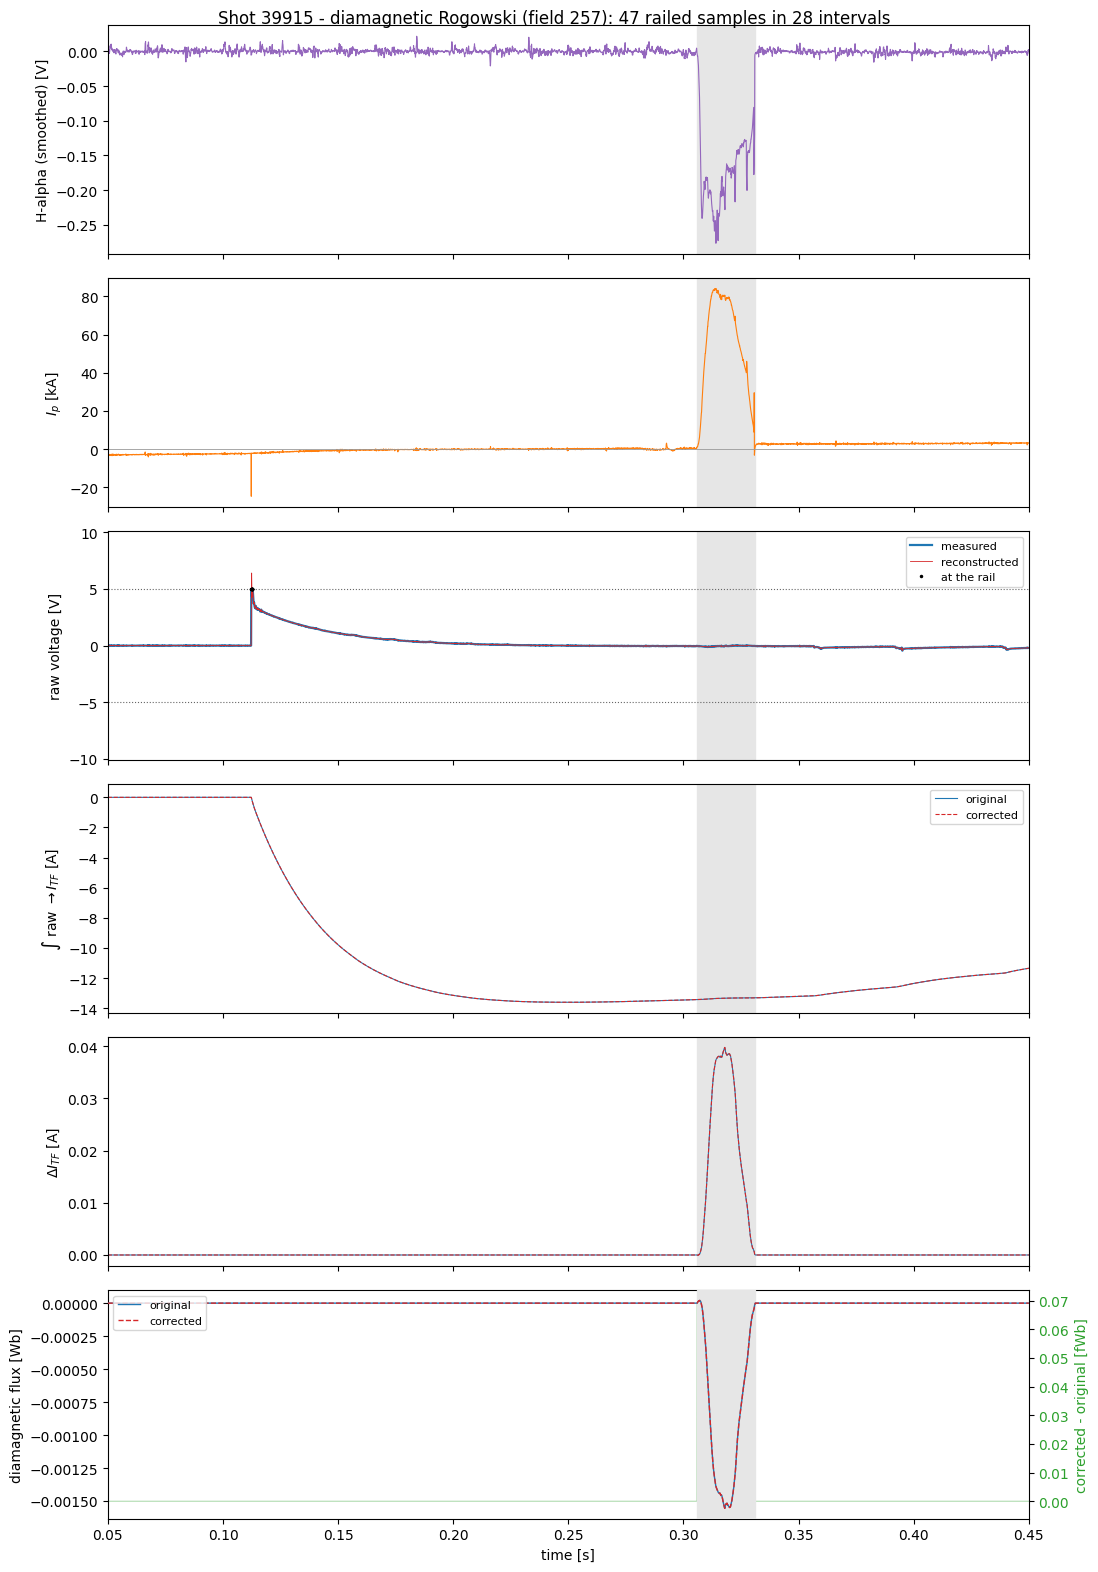

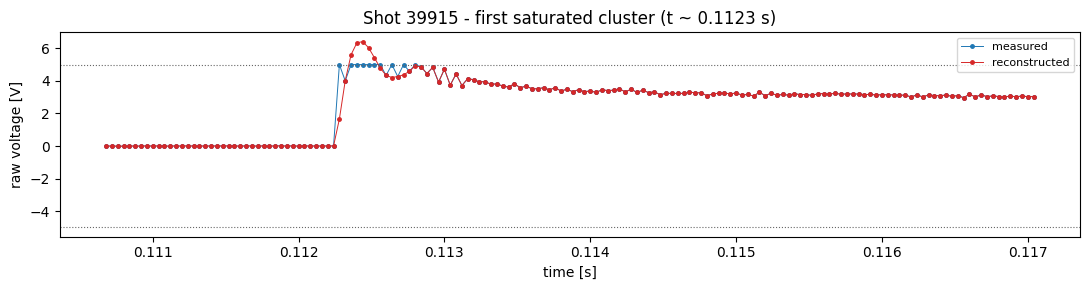

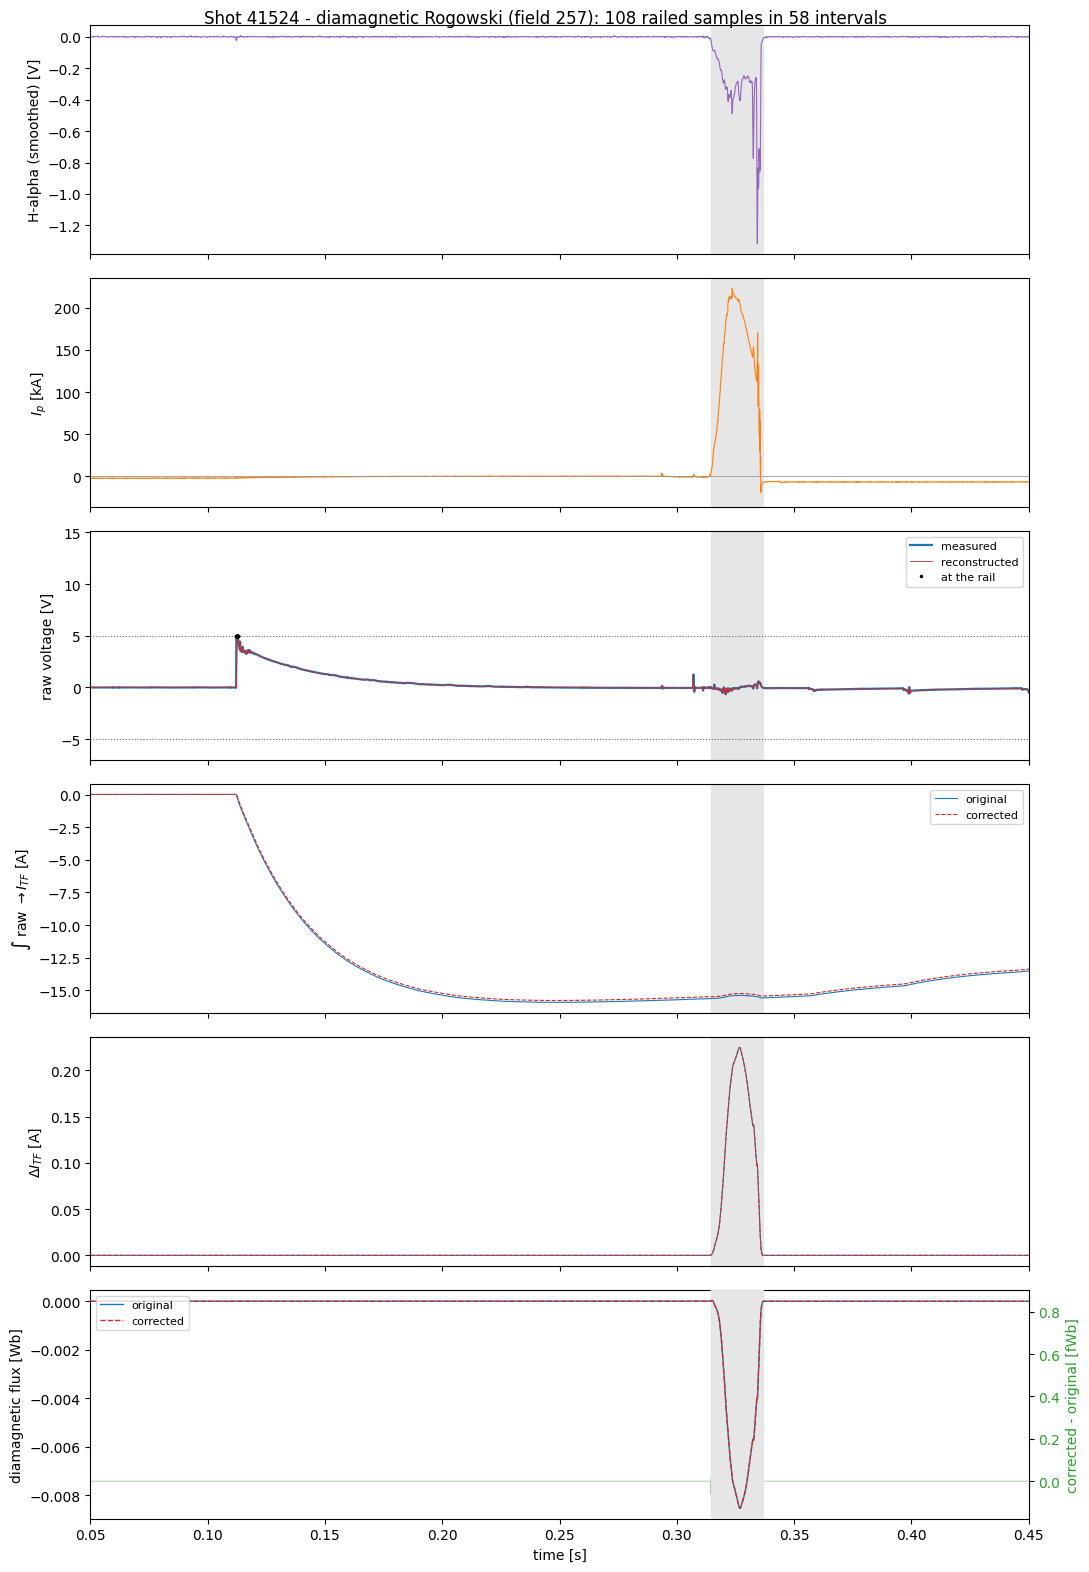

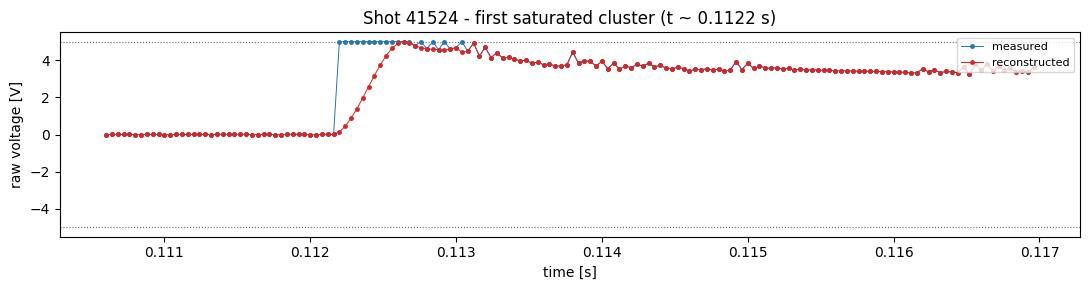

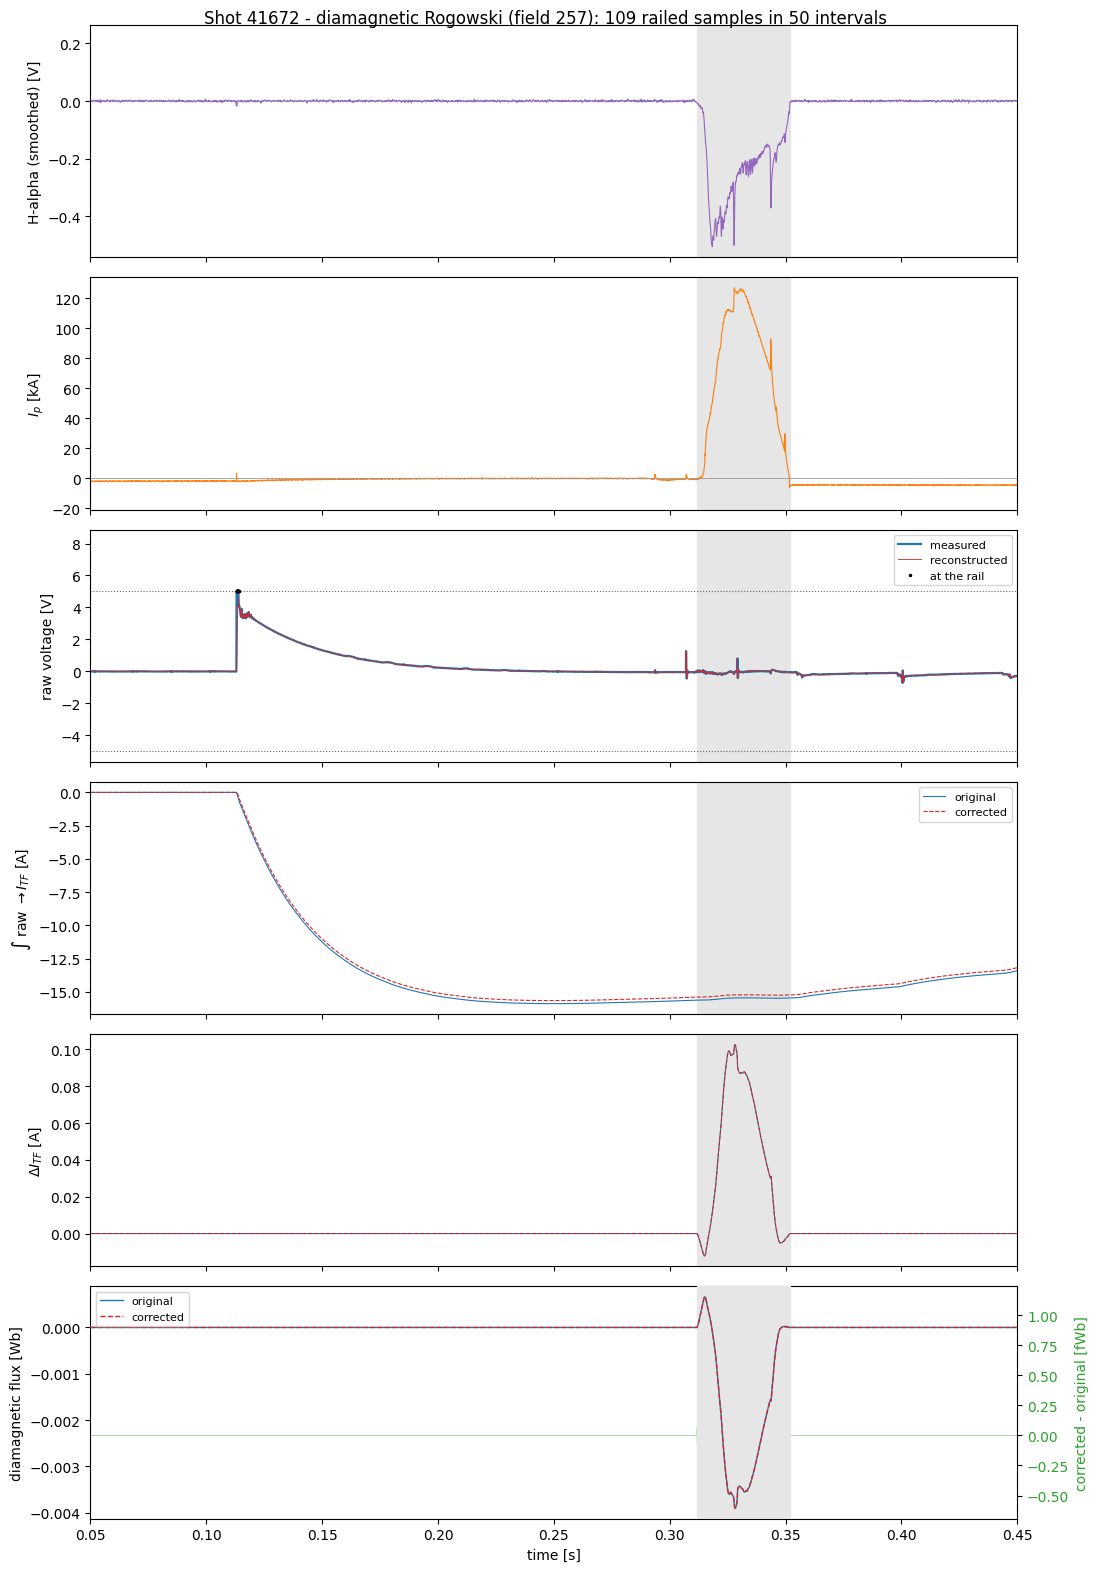

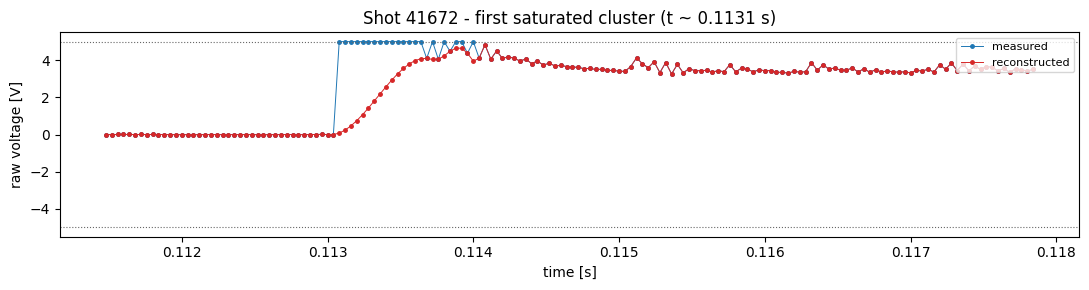

In [ ]:
def compare_shot(shot):
    ctx = contexts[shot]
    original = chains[shot]["original"]["stages"]
    corrected = chains[shot]["corrected"]["stages"]
    time = corrected["time"]
    mask = corrected["saturated"]
    report = chains[shot]["corrected"]

    fig, axes = plt.subplots(6, 1, figsize=(11, 16), sharex=True)
    fig.suptitle(
        f"Shot {shot} - diamagnetic Rogowski (field {report['field']}): "
        f"{report['n_saturated']} railed samples in {report['n_intervals']} intervals",
        fontsize=12,
    )

    for ax in axes:
        ax.axvspan(ctx["plasma_start"], ctx["plasma_end"], color="0.9", zorder=0)

    axes[0].plot(ctx["halpha_time"], ctx["halpha"], lw=0.8, color="tab:purple")
    axes[0].set_ylabel("H-alpha (smoothed) [V]")

    axes[1].plot(ctx["ip_time"], ctx["ip"] / 1e3, lw=0.8, color="tab:orange")
    axes[1].axhline(0.0, color="0.6", lw=0.6)
    axes[1].set_ylabel(r"$I_p$ [kA]")

    ax = axes[2]
    ax.plot(time, original["raw"], lw=1.6, color="tab:blue", label="measured")
    ax.plot(time, corrected["raw_repaired"], lw=0.6, color="tab:red", label="reconstructed")
    for level in report["clip_values"]:
        ax.axhline(level, color="0.4", ls=":", lw=0.8)
    ax.plot(time[mask], original["raw"][mask], ".", ms=3, color="k", label="at the rail")
    ax.set_ylabel("raw voltage [V]")
    ax.legend(loc="upper right", fontsize=8)

    axes[3].plot(time, original["integrated"], lw=0.8, color="tab:blue", label="original")
    axes[3].plot(time, corrected["integrated"], lw=0.8, color="tab:red", ls="--", label="corrected")
    axes[3].set_ylabel(r"$\int$ raw $\rightarrow I_{TF}$ [A]")
    axes[3].legend(loc="upper right", fontsize=8)

    axes[4].plot(time, original["delta_i_tf"], lw=0.8, color="tab:blue")
    axes[4].plot(time, corrected["delta_i_tf"], lw=0.8, color="tab:red", ls="--")
    axes[4].set_ylabel(r"$\Delta I_{TF}$ [A]")

    ax = axes[5]
    ax.plot(time, original["flux"], lw=1.0, color="tab:blue", label="original")
    ax.plot(time, corrected["flux"], lw=1.0, color="tab:red", ls="--", label="corrected")
    ax.set_ylabel("diamagnetic flux [Wb]")
    ax.set_xlabel("time [s]")
    ax.set_xlim(0.05, 0.45)
    ax.legend(loc="upper left", fontsize=8)

    # The residual is ~1e-15 Wb, so it is shown in femtoweber to stay readable.
    # The twin axis is pushed behind the flux traces, otherwise the noise-like
    # residual paints over the waveform it is meant to annotate.
    residual = 1e15 * (corrected["flux"] - original["flux"])
    twin = ax.twinx()
    twin.plot(time, residual, lw=0.6, color="tab:green", alpha=0.5)
    twin.set_ylabel("corrected - original [fWb]", color="tab:green")
    twin.tick_params(axis="y", labelcolor="tab:green")
    twin.set_zorder(ax.get_zorder() - 1)
    ax.set_frame_on(False)

    fig.tight_layout()
    plt.show()

    # Zoom on the first saturated cluster, where the reconstruction is visible.
    first = int(np.flatnonzero(mask)[0])
    lo, hi = max(first - 40, 0), min(first + 120, time.size)
    fig, ax = plt.subplots(figsize=(11, 3))
    ax.plot(time[lo:hi], original["raw"][lo:hi], "-o", ms=2.5, lw=0.7, color="tab:blue", label="measured")
    ax.plot(time[lo:hi], corrected["raw_repaired"][lo:hi], "-o", ms=2.5, lw=0.7, color="tab:red", label="reconstructed")
    for level in report["clip_values"]:
        ax.axhline(level, color="0.4", ls=":", lw=0.8)
    ax.set_title(f"Shot {shot} - first saturated cluster (t ~ {time[first]:.4f} s)")
    ax.set_xlabel("time [s]")
    ax.set_ylabel("raw voltage [V]")
    ax.legend(loc="upper right", fontsize=8)
    fig.tight_layout()
    plt.show()


for shot in SHOTS:
    compare_shot(shot)

#### What the zoom shows — and a caveat worth recording

The first cluster is the TF capacitor bank firing: the measured trace steps to the rail in a
single sample and stays there for ~15 samples. The cubic reconstruction, fitted to the
unsaturated samples on either side, turns that step into a gradual ramp — it is bounded by
real data, so `repair_clipped_interval`'s precondition is satisfied, but a step edge is not
*constrained* by it. The reconstruction there is very likely an underestimate of the true
overshoot.

The visible consequence is the ~0.3 A offset between the original and corrected `I_TF` traces
in panel 2. It does not reach the flux, because the reference subtraction removes any offset
common to the window and its surroundings — which is exactly why panels 3 and 4 lie on top of
each other. Recorded here so the limitation is on the record rather than implied by the
0.00 % result: for this channel the repair is a guard against in-window clipping, not a
claim that the bank-fire transient has been recovered.

### Quantification

Issue #285 asks for the size of the error on `magnetics.diamagnetic_flux[0]` for the three
packaged shots to be put on record. `max |Δ|` below is taken **inside the detected plasma
window**, where the mapped waveform is non-zero; the window and the peak plasma current are
listed alongside so the comparison is anchored to the discharge, not to a fixed time span.

In [ ]:
rows = []
for shot in SHOTS:
    ctx = contexts[shot]
    original = chains[shot]["original"]["stages"]
    corrected = chains[shot]["corrected"]["stages"]
    report = chains[shot]["corrected"]
    time = corrected["time"]
    raw = original["raw"]
    mask = corrected["saturated"]
    window = (time >= ctx["plasma_start"]) & (time <= ctx["plasma_end"])

    peak = np.abs(original["flux"][window]).max()
    delta = np.abs(corrected["flux"][window] - original["flux"][window]).max()
    rows.append(
        {
            "shot": shot,
            "field": report["field"],
            "window [s]": f"{ctx['plasma_start']:.4f}-{ctx['plasma_end']:.4f}",
            "peak |Ip| [kA]": np.abs(ctx["ip"]).max() / 1e3,
            "at -5.000 V": int(np.count_nonzero(mask & (raw < 0))),
            "at +4.999847 V": int(np.count_nonzero(mask & (raw > 0))),
            "intervals": report["n_intervals"],
            "longest run": report["longest_run"],
            "in plasma window": report["n_saturated_in_window"],
            "peak |flux| [Wb]": peak,
            "max |delta| [Wb]": delta,
            "relative": f"{100 * delta / peak:.2e} %",
        }
    )

pd.DataFrame(rows).set_index("shot")

       field     window [s]  peak |Ip| [kA]  at -5.000 V  at +4.999847 V  \
shot                                                                       
39915    257  0.3060-0.3312       84.137219           34              13   
41524    257  0.3144-0.3367      223.148997           71              37   
41672    257  0.3118-0.3519      127.042818           66              43   

       intervals  longest run  in plasma window  peak |flux| [Wb]  \
shot                                                                
39915         28            6                 0          0.001556   
41524         58           11                 0          0.008547   
41672         50           15                 0          0.003900   

       max |delta| [Wb]    relative  
shot                                 
39915      7.003946e-17  4.50e-12 %  
41524      8.534840e-16  9.99e-12 %  
41672      1.152941e-15  2.96e-11 %  

### What the numbers say

The correction moves the packaged waveforms by **less than 1e-15 Wb — 0.00 %**. That is a
real result, not a failed test, and it has a specific mechanism:

- every saturated sample on these three shots lies **outside** the plasma window (two clusters,
  near *t* ≈ 0.113 s when the TF bank fires, and after *t* ≈ 0.77 s), while the detected
  windows are 0.306–0.331, 0.314–0.337 and 0.312–0.352 s — all inside the shared 0.28–0.36 s range
  `detect_plasma_window` searches;
- the clipping therefore enters `I_TF` as an offset that is common to both the signal and the
  reference interpolated across the window, so the reference subtraction cancels it, and the
  two-point linear baseline removes whatever survives.

So the accumulation argument in the issue is correct in general but does not bite for *this*
window geometry. What the change buys is the case the packaged data happens not to contain:

- if saturation ever falls **inside** the plasma window, it is now reconstructed before the
  first integration instead of being integrated three times, and a `RuntimeWarning` is raised
  because the in-window waveform is then an interpolation rather than a measurement;
- if the saturated interval runs to either end of the record, `SignalRepairError` propagates
  rather than a fabricated waveform being returned;
- the outcome is recorded in `magnetics.diamagnetic_flux[0].method_name`, and
  `diamagnetic_saturation_report()` gives a structured version for the
  `magnetics.rogowski_coil[:].current.validity` mapping in issue #215 — the IMAS DD has no
  `validity` field under `magnetics.diamagnetic_flux` itself.

The panels also settle the physics check the mapping rests on: `ΔI_TF` and the diamagnetic
flux are non-zero only where H-alpha dips and `Ip` is up, and the flux is negative throughout
— diamagnetic, as it should be for a confined plasma.

`test/test_diamagnetic_flux_saturation.py` locks the null result in place, so a future change
that starts moving these three waveforms shows up as a test failure rather than as silent
drift.

In [ ]:
ods = {}
magnetics.diamagnetic_flux_rogowski_coil_from_raw_database(ods, 41672, raw_source=RAW_SOURCE)
print(ods["magnetics"]["diamagnetic_flux"][0]["method_name"])

Rogowski triple-integration of VEST raw field 257; 109/25000 samples reconstructed at the acquisition limit in 50 intervals, 0 inside the plasma window
